In [1]:
from preprocessing.load_dataset import SubCorBatDataset
import pandas as pd
import os

### Input data
# Path to dataset
DATA_PATH = "/mimer/NOBACKUP/groups/biomedicalimaging-kth/felixnie/"
load_ds_path = DATA_PATH + "batched_adni/"
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_vae_path = ""#"./data/pretrained_models/autoencoder_puglisi.pth"
# Pretrained weights for the Discriminator
ckpt_dis_path = ""#"./data/pretrained_models/ckpt_dis_.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]



# Load metadata
index_ds = pd.read_csv(os.path.join(DATA_PATH,"dataset_index.csv"))
clinical_ds = pd.read_csv(os.path.join(DATA_PATH,"combined_metadata.csv"))
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)
print(f"METADATA: Remaining rows: {len(metadata)}") # Check result

# Load labels


# Training configuration
batch_files = sorted(metadata["batch_file"].unique())

# Load labels and bounding boxes
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column


METADATA: Original rows: 988
METADATA: Remaining rows: 988


In [2]:
dataset = SubCorBatDataset(metadata, batch_files[0], labels_bb_df, n_structs=10)

In [3]:
labels_bb_df

,LabelID,MapID,LabelName,R,G,B,A,Use,min_x,min_y,...,extent_z,common_extent_x,common_extent_y,common_extent_z,common_min_x,common_min_y,common_min_z,common_max_x,common_max_y,common_max_z
0,1,1,Left-Cerebral-Exterior,70,130,180,0,0,NaN,NaN,...,NaN,96,144,192,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2,Left-Cerebral-White-Matter,245,245,245,0,1,78.0,12.0,...,177.0,96,144,192,64.0,2.0,2.0,160.0,146.0,194.0
2,3,3,Left-Cerebral-Cortex,205,62,78,0,0,NaN,NaN,...,NaN,96,144,192,NaN,NaN,NaN,NaN,NaN,NaN
3,4,4,Left-Lateral-Ventricle,120,18,134,0,1,79.0,54.0,...,118.0,96,144,192,51.0,6.0,0.0,147.0,150.0,192.0
4,5,5,Left-Inf-Lat-Vent,196,58,250,0,1,99.0,92.0,...,40.0,96,144,192,62.0,35.0,0.0,158.0,179.0,192.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,2031,166,ctx-rh-supramarginal,80,160,20,0,1,10.0,30.0,...,48.0,96,144,192,0.0,0.0,0.0,96.0,144.0,192.0
166,2032,167,ctx-rh-frontalpole,100,0,100,0,1,59.0,83.0,...,21.0,96,144,192,21.0,27.0,85.0,117.0,171.0,277.0
167,2033,168,ctx-rh-temporalpole,70,70,70,0,1,34.0,110.0,...,27.0,96,144,192,1.0,52.0,34.0,97.0,196.0,226.0
168,2034,169,ctx-rh-transversetemporal,150,150,200,0,1,20.0,71.0,...,30.0,96,144,192,0.0,10.0,3.0,96.0,154.0,195.0


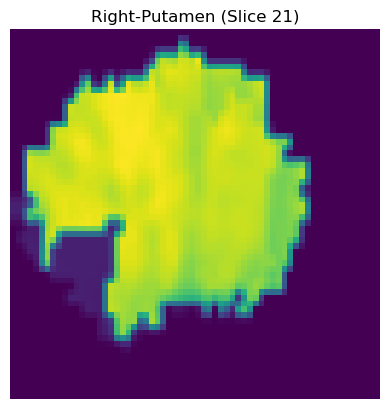

In [28]:
import matplotlib.pyplot as plt
import torch

%matplotlib inline

i_sub = 10
i_str = 5

sample = dataset[i_sub]
struct = sample["image"][i_str, 0]  # [D, H, W]

# Find the z-slice (axial) where the structure has the highest total intensity
z_profile = struct.sum(axis=(1, 2))  # Sum over H and W → shape: [D]
z_max = torch.argmax(z_profile).item()

# Plot that slice
plt.imshow(struct[z_max].cpu())
plt.title(f"{sample['struct_name'][i_str]} (Slice {z_max})")
plt.axis('off')
plt.show()


In [5]:
np.argmax(sample["image"][i])

NameError: name 'np' is not defined